In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [211]:
from sklearn.datasets import make_blobs
x, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.70)

In [212]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head(10)


,feature1,feature2
0,9.423338,8.465711
1,7.767662,7.602345
2,4.831631,-6.581466
3,9.822323,1.508882
4,9.297362,8.363637
5,10.784215,1.070023
6,-7.408949,-4.760345
7,-7.985805,-3.660010
8,9.144980,8.877574
9,-6.371039,-4.266499


In [213]:
df.shape

(500, 2)

In [214]:

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
print(x_scaled[:5])


[[ 0.8098034   1.50447286]
 [ 0.5577234   1.35626739]
 [ 0.11070693 -1.07852532]
 [ 0.87054955  0.31026362]
 [ 0.79062333  1.48695079]]


In [215]:

kmeans = KMeans(n_clusters=3)
lables = kmeans.fit_predict(x_scaled)
df["Cluster_lables"] = lables
print("First 10 rows of the dataframe:")
df.head(10)

First 10 rows of the dataframe:


,feature1,feature2,Cluster_lables
0,9.423338,8.465711,0
1,7.767662,7.602345,0
2,4.831631,-6.581466,2
3,9.822323,1.508882,0
4,9.297362,8.363637,0
5,10.784215,1.070023,0
6,-7.408949,-4.760345,1
7,-7.985805,-3.660010,1
8,9.144980,8.877574,0
9,-6.371039,-4.266499,1


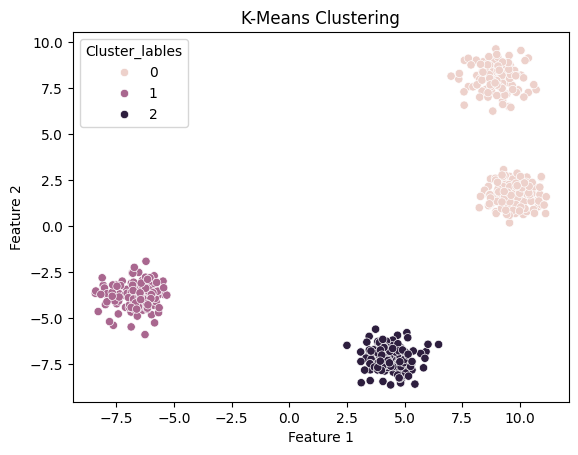

In [216]:

sns.scatterplot(x="feature1", y="feature2", hue="Cluster_lables", data=df)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

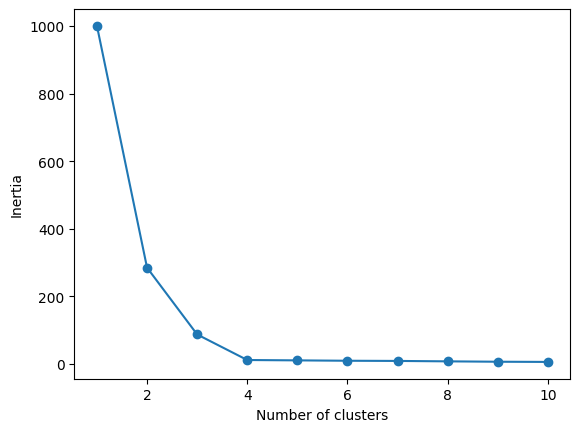

In [217]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)
plt.plot(k_value, errors, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [218]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())

final_Cluster
1    125
2    125
3    125
0    125
Name: count, dtype: int64


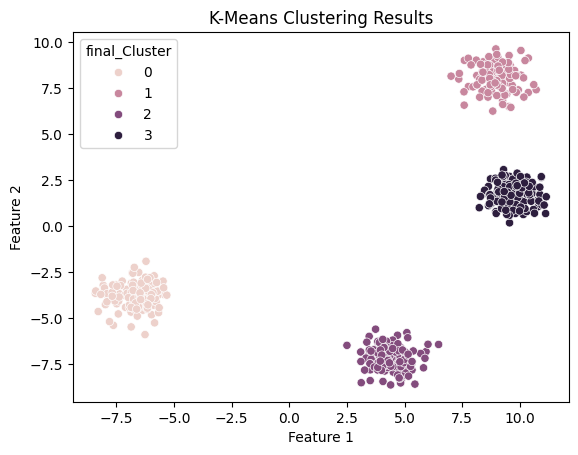

In [219]:
sns.scatterplot(x="feature1", y="feature2", hue="final_Cluster", data=df)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Iris


In [220]:
from sklearn.datasets import load_iris
iris=load_iris()

In [221]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
kmeans=KMeans(n_clusters=3, random_state=42)
df["Cluster"]=kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


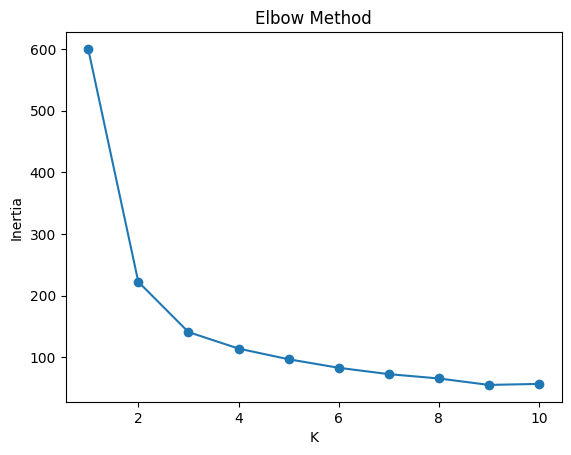

In [222]:
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [223]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["final_Cluster"] = kmeans.fit_predict(x_scaled)
print(df["final_Cluster"].value_counts())


final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


shape of the dataset:
(150, 4)
first 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None
Summary:
       sepal length (cm)  sepal width (cm)  petal len

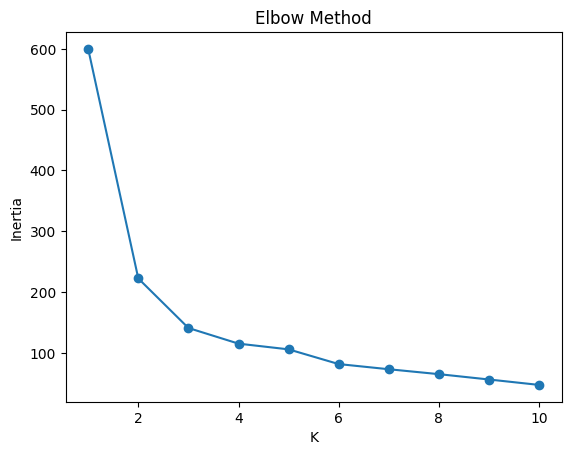

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


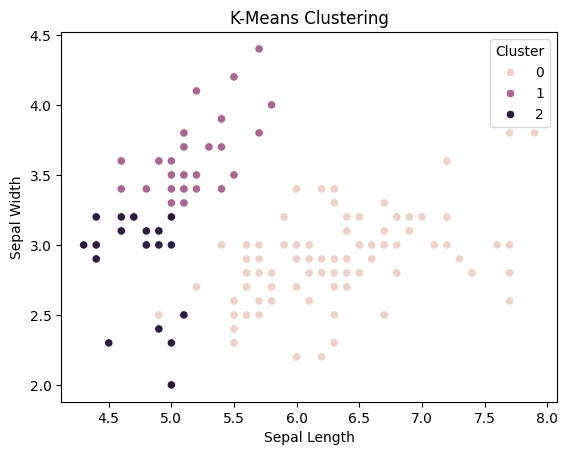

In [224]:
# Load dataset
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

print("shape of the dataset:")
print(df.shape)

print("first 5 rows:")
print(df.head())
print(df.info())

print("Summary:")
print(df.describe())

# Select numerical features
X = df

#Scalling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("First 5 rows of scaled data:")
print(X_scaled[:5])

# Elbow Method
errors = []
k_value = range(1, 11)
for k in k_value:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    errors.append(kmeans.inertia_)

plt.plot(k_value, errors, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Final Model
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(x_scaled)
print(df["Cluster"].value_counts())

# Visualization
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="Cluster", data=df)
plt.title("K-Means Clustering")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()